In [12]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [13]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        pass

In [14]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [15]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [16]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
       return state == self.goal
    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        legal_actions = []
        row, col = state
        for action, (dr, dc) in MOVES.items():
            next_state = (row + dr, col + dc)
            if self.in_bounds(next_state) and self.is_free(next_state):
                legal_actions.append(action)
        return legal_actions
       
    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        row, col = state
        dr, dc = MOVES[action]

        return (row + dr, col + dc)
    
    def action_cost(
    self,
    state: Tuple[int, int],
    action: str,
    next_state: Tuple[int, int],
) -> float:
        return 1 
   

   

In [17]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [36]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [40]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

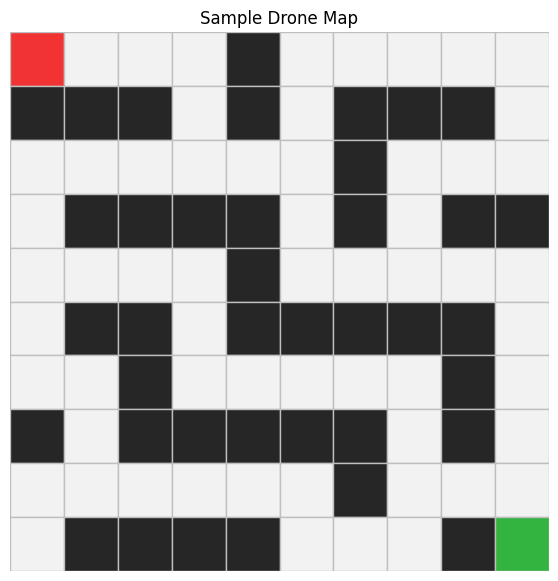

In [41]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [18]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        state = node.state

        for action in problem.actions(state):
            next_state = problem.result(state, action)

            cost = (
                node.path_cost
                + problem.action_cost(state, action, next_state)
            )

            yield Node(
                state=next_state,
                parent=node,
                action=action,
                path_cost=cost,
            )

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [27]:
class BreadthFirstSearch(SearchAlgorithm):

    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        node = Node(problem.initial_state())

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1,
            )

        frontier = deque([node])
        reached = {node.state}

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):

                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                    )

                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)

            max_frontier_size = max(
                max_frontier_size,
                len(frontier)
            )

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

In [34]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        node = Node(problem.initial_state())

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1,
            )

        frontier = [node]
        reached = {node.state}

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.pop()
            nodes_expanded += 1

            children = list(self.expand(problem, node))
            children.reverse()

            for child in children:

                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                    )

                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)

            max_frontier_size = max(
                max_frontier_size,
                len(frontier)
            )

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

In [29]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        node = Node(problem.initial_state())

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1,
            )

        frontier = [node]
        reached = {node.state}

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.pop()
            nodes_expanded += 1

            children = list(self.expand(problem, node))
            children.reverse()

            for child in children:

                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                    )

                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)

            max_frontier_size = max(
                max_frontier_size,
                len(frontier)
            )

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

In [32]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:

        if problem.is_goal(node.state):
            return node, "success"

        elif node.depth >= limit:
            return None, "cutoff"

        metrics["nodes_expanded"] += 1
        cutoff_occurred = False

        for child in self.expand(problem, node):

            if state_is_on_path(node, child.state):
                continue

            metrics["max_stack_size"] = max(
                metrics["max_stack_size"],
                current_stack_size + 1,
            )

            result, status = self._recursive_dls(
                problem=problem,
                node=child,
                limit=limit,
                metrics=metrics,
                current_stack_size=current_stack_size + 1,
            )

            if status == "success":
                return result, "success"

            elif status == "cutoff":
                cutoff_occurred = True

        if cutoff_occurred:
            return None, "cutoff"

        return None, "failure"

In [30]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        dls = DepthLimitedSearch()

        iteration_log = []
        total_nodes_expanded = 0
        max_stack_size = 0

        for limit in range(max_depth + 1):

            result = dls.search(problem, limit=limit)

            iteration_log.append({
                "limit": limit,
                "status": result.status,
            })

            total_nodes_expanded += result.nodes_expanded

            max_stack_size = max(
                max_stack_size,
                result.max_frontier_size,
            )

            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    reached_count=0,
                    iterations=iteration_log,
                )

            if result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    reached_count=0,
                    iterations=iteration_log,
                )

        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size,
            reached_count=0,
            iterations=iteration_log,
        )

In [37]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,26.0,26.0,37,4,39
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,NaN,18.0,18.0,356,19,0


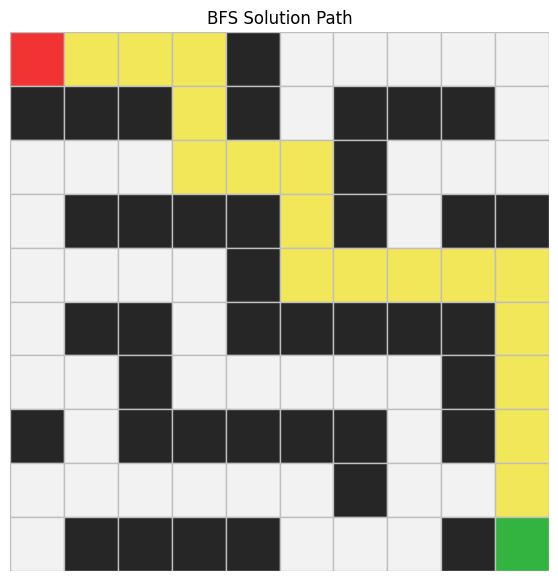

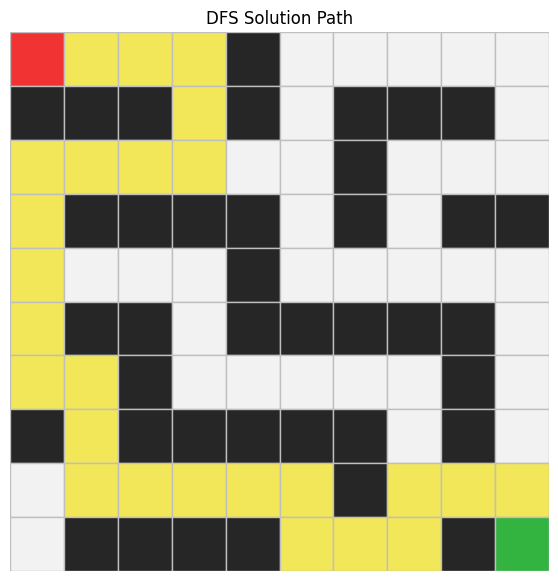

In [42]:
bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [43]:
custom_grid_1 = [
    [0,0,0,0,0],
    [1,1,1,1,0],
    [0,0,0,0,0],
    [0,1,1,1,1],
    [0,0,0,0,0],
]

custom_start_1 = (0,0)
custom_goal_1 = (4,4)

custom_problem_1 = GridProblem(
    custom_grid_1,
    custom_start_1,
    custom_goal_1
)

custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]

show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,16,16,16,1,16
1,DFS,success,NaN,16,16,16,1,16
2,DLS,success,20.0,16,16,16,17,0
3,IDS,success,NaN,16,16,136,17,0


In [46]:
large_map = [
[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[1,1,1,1,1,0,1,1,1,1,1,1,1,1,0],
[0,0,0,0,1,0,0,0,0,0,0,0,0,1,0],
[0,1,1,0,1,1,1,1,1,1,1,1,0,1,0],
[0,1,0,0,0,0,0,0,0,0,0,1,0,1,0],
[0,1,0,1,1,1,1,1,1,1,0,1,0,1,0],
[0,1,0,1,0,0,0,0,0,1,0,1,0,1,0],
[0,1,0,1,0,1,1,1,0,1,0,1,0,1,0],
[0,1,0,1,0,1,0,1,0,1,0,1,0,1,0],
[0,1,0,1,0,1,0,1,0,1,0,1,0,1,0],
[0,1,0,1,0,1,0,1,0,1,0,1,0,1,0],
[0,1,0,1,0,1,0,1,0,1,0,1,0,1,0],
[0,1,0,0,0,1,0,0,0,1,0,0,0,1,0],
[0,1,1,1,0,1,1,1,0,1,1,1,0,1,0],
[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
]

large_start = (0,0)
large_goal = (8,6)

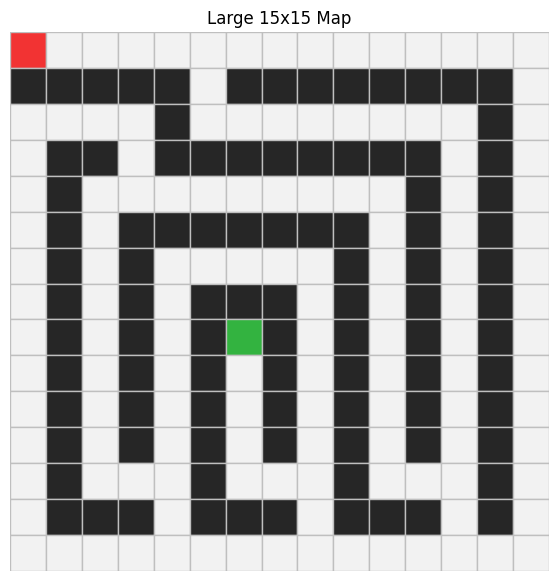

In [47]:
plot_path(
    large_map,
    large_start,
    large_goal,
    title="Large 15x15 Map"
)

In [48]:
large_problem = GridProblem(
    large_map,
    large_start,
    large_goal
)

large_results = [
    bfs.search(large_problem),
    dfs.search(large_problem),
    dls.search(large_problem, limit=40),
    ids.search(large_problem, max_depth=50),
]

show_results(large_results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,38,38,87,6,92
1,DFS,success,NaN,38,38,104,9,108
2,DLS,success,40.0,38,38,45,41,0
3,IDS,success,NaN,38,38,1443,39,0


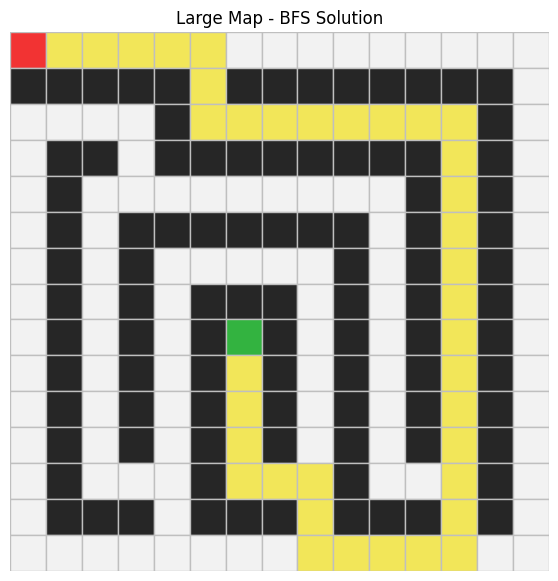

In [49]:
plot_path(
    large_map,
    large_start,
    large_goal,
    path=large_results[0].path,
    title="Large Map - BFS Solution"
)

This map was made significantly larger than the previous maps and contains many obstacles that force the algorithms to navigate through narrow passages. BFS successfully finds the shortest path but expands many nodes. DFS explores deeper routes first and may take longer to locate the goal. IDS eventually finds the same solution as BFS but performs repeated searches at increasing depth limits, resulting in additional node expansions.

In [50]:
corridor_map = [
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
]

corridor_start = (0,0)
corridor_goal = (0,19)

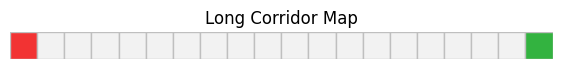

In [51]:
plot_path(
    corridor_map,
    corridor_start,
    corridor_goal,
    title="Long Corridor Map"
)

In [52]:
corridor_problem = GridProblem(
    corridor_map,
    corridor_start,
    corridor_goal
)

corridor_results = [
    bfs.search(corridor_problem),
    dfs.search(corridor_problem),
    dls.search(corridor_problem, limit=25),
    ids.search(corridor_problem, max_depth=25),
]

show_results(corridor_results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,19,19,19,1,19
1,DFS,success,NaN,19,19,19,1,19
2,DLS,success,25.0,19,19,19,20,0
3,IDS,success,NaN,19,19,190,20,0


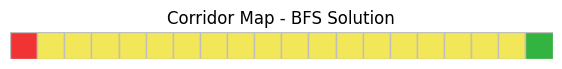

In [53]:
plot_path(
    corridor_map,
    corridor_start,
    corridor_goal,
    path=corridor_results[0].path,
    title="Corridor Map - BFS Solution"
)

This map consists of a single long corridor connecting the start state to the goal state. There are no branches, obstacles, or alternative routes. The purpose of this map is to test the basic functionality of the search algorithms in a simple environment where only one valid path exists. All four algorithms successfully found the goal because there is only one possible route. Since no decisions or backtracking are required, BFS, DFS, DLS, and IDS produce the same solution path. The main difference is that IDS may expand slightly more nodes due to repeatedly searching with increasing depth limits.

## Reflection Questions 
15.1
A state is the drone's current position on the grid, represented as a coordinate
An action is a movement the drone can make, such as UP, DOWN, LEFT, or RIGHT.
The result function returns the new state after an action is applied to the current state.
It allows the same search algorithm to be used on different problems without changing the algorithm itself.


15.2
BFS uses FIFO queue beacause it explores states in the order they were discovered.
BFS find the shortest path in terms of number of steps on the unweighted grid beacuse it explores all nodes at one depth before moving to a deeper level.
Reached prevents the algorithm from revisiting states that have already been explored.

15.3
1. DFS use a stack because it follows one path as deeply as possible before backtracking.
2. No. DFS may find a longer path before finding the shortest one.
3. DFS use less memory than BFS When the search space is very large and the solution is deep.
4. DFS perform badly when there are many dead ends or very deep branches.


15.4
1. when the depth limit is too small the algorithm may fail to reach the goal.
2. "cutoff" means the search stopped because the depth limit was reached.
3. DLS different from ordinary DFS because DLS restricts how deep the search can go.
4. We use path-cycle checking in DLS To prevent the search from repeatedly visiting states already on the current path.

15.5
1. IDS repeat DLS with increasing limits to gradually search deeper until the goal is found.
2. IDS be complete even though DLS with a small limit is not because IDS eventually increases the depth limit enough to reach the goal.
3. IDS use less memory than BFS because it only stores nodes along the current search path
4. The cost of repeatedly searching from the root is that some nodes are expanded multiple times, increasing computation.

15.6
1. what might make one route safer or more practical than another are factors such as obstacles, weather conditions, battery usage, and restricted areas.
2. BFS, because it guarantees the shortest path on an unweighted grid.
3. DLS, because it allows a maximum search depth to be specified.
4. It does not account for weather, terrain elevation, battery constraints, moving obstacles, or GPS uncertainty.
